### 1. Chargement des données brutes  

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

DATA_PATH = Path('../data/raw/heart_disease_uci.csv')
PROC_PATH = Path('../data/processed')
FIGS_PATH = Path('../reports/figures')

# Colonnes par type
NUM_COLS = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'chol_per_age', 'thalch_ratio']
BIN_COLS = ['fbs', 'exang', 'ca_missing', 'thal_missing']
OHE_COLS = ['cp', 'thal', 'dataset']
LBL_COLS = ['sex', 'restecg', 'slope']
TARGET   = 'num'

df = pd.read_csv(DATA_PATH)
df = df.drop(columns=['id'])
print(f'Données chargées : {df.shape[0]} lignes × {df.shape[1]} colonnes')

Données chargées : 920 lignes × 15 colonnes


### 2 — Nettoyage des valeurs aberrantes

Corrections appliquées :
  chol = 0     → NaN : 172 valeurs
  trestbps = 0 → NaN : 1 valeur
  oldpeak < 0  → 0   : 12 valeurs


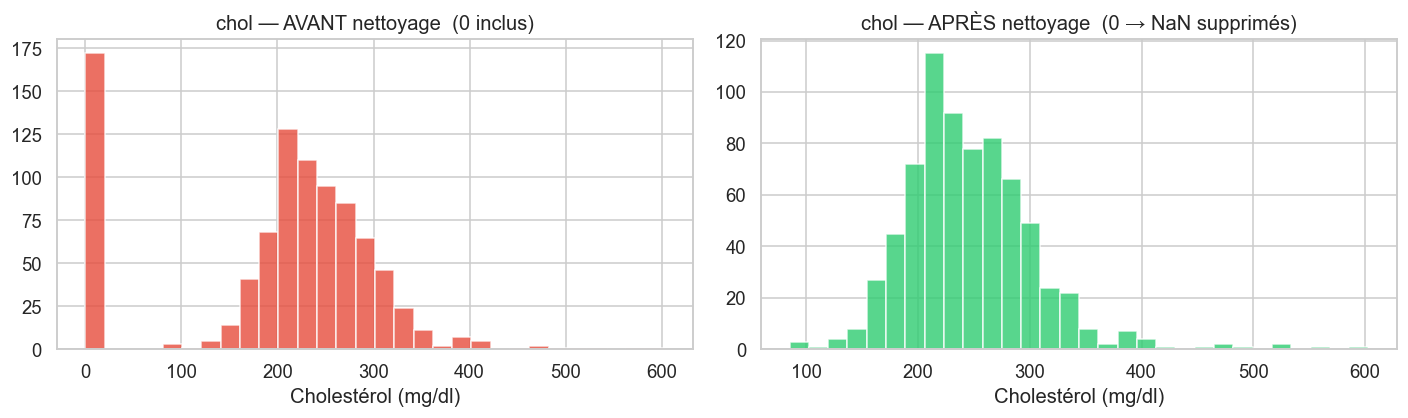

In [6]:
df_before = df.copy()

# chol = 0 → NaN
n_chol = (df['chol'] == 0).sum()
df.loc[df['chol'] == 0, 'chol'] = np.nan

# trestbps = 0 → NaN
n_bps = (df['trestbps'] == 0).sum()
df.loc[df['trestbps'] == 0, 'trestbps'] = np.nan

# oldpeak < 0 → 0
n_old = (df['oldpeak'] < 0).sum()
df.loc[df['oldpeak'] < 0, 'oldpeak'] = 0.0

print(f'Corrections appliquées :')
print(f'  chol = 0     → NaN : {n_chol} valeurs')
print(f'  trestbps = 0 → NaN : {n_bps} valeur')
print(f'  oldpeak < 0  → 0   : {n_old} valeurs')

# Visualisation avant/après pour chol
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df_before['chol'].dropna(), bins=30, color='#e74c3c', edgecolor='white', alpha=0.8)
axes[0].set_title('chol — AVANT nettoyage  (0 inclus)')
axes[0].set_xlabel('Cholestérol (mg/dl)')
axes[1].hist(df['chol'].dropna(), bins=30, color='#2ecc71', edgecolor='white', alpha=0.8)
axes[1].set_title('chol — APRÈS nettoyage  (0 → NaN supprimés)')
axes[1].set_xlabel('Cholestérol (mg/dl)')
plt.tight_layout()
plt.savefig(FIGS_PATH / '08_chol_before_after.png', dpi=150, bbox_inches='tight')
plt.show()

### 3 — Binarisation de la cible + typage des booléens

In [7]:
print(f'Distribution cible brute : {dict(df[TARGET].value_counts().sort_index())}')  # distribution avant transformation

# Binarisation : 0 = sain, 1 = malade
df[TARGET] = (df[TARGET] > 0).astype(int)  # conversion en problème binaire
print(f'Distribution cible binaire : {dict(df[TARGET].value_counts().sort_index())}')  # distribution après binarisation

# fbs / exang : True/False → 0/1
for col in ['fbs', 'exang']:
    df[col] = df[col].map({True: 1, False: 0, 'True': 1, 'False': 0})  # encodage binaire
    print(f'{col} → dtype après cast : {df[col].dtype}  |  manquants : {df[col].isna().sum()}')  # vérification

Distribution cible brute : {0: np.int64(411), 1: np.int64(265), 2: np.int64(109), 3: np.int64(107), 4: np.int64(28)}
Distribution cible binaire : {0: np.int64(411), 1: np.int64(509)}
fbs → dtype après cast : float64  |  manquants : 90
exang → dtype après cast : float64  |  manquants : 55


### 4 — Feature Engineering

ca_missing   : 611 patients sans ca (66.4%)
thal_missing : 486 patients sans thal (52.8%)

chol_per_age  — min=1.52  max=16.53  mean=4.81
thalch_ratio  — min=0.355  max=1.175  mean=0.824


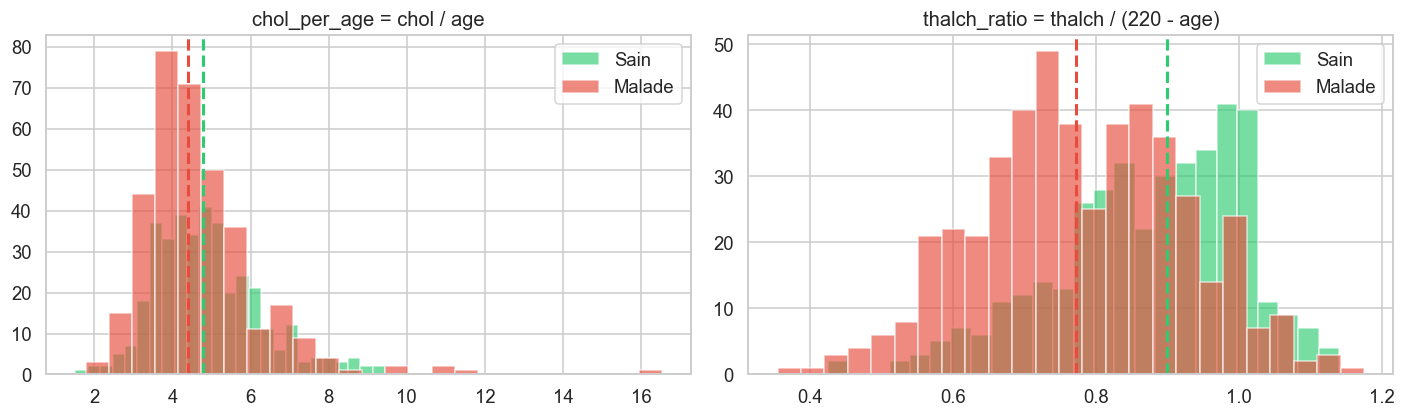

In [8]:
# Flags manque AVANT imputation (sinon perte d'information)
df['ca_missing']   = df['ca'].isna().astype(int)
df['thal_missing'] = df['thal'].isna().astype(int)

print(f'ca_missing   : {df["ca_missing"].sum()} patients sans ca ({df["ca_missing"].mean():.1%})')
print(f'thal_missing : {df["thal_missing"].sum()} patients sans thal ({df["thal_missing"].mean():.1%})')

# Features dérivées cliniques
df['chol_per_age'] = df['chol'] / df['age']
df['thalch_ratio'] = df['thalch'] / (220 - df['age']).clip(lower=1)

print(f'\nchol_per_age  — min={df["chol_per_age"].min():.2f}  max={df["chol_per_age"].max():.2f}  mean={df["chol_per_age"].mean():.2f}')
print(f'thalch_ratio  — min={df["thalch_ratio"].min():.3f}  max={df["thalch_ratio"].max():.3f}  mean={df["thalch_ratio"].mean():.3f}')

# Visualisation des nouvelles features
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, title in [
    (axes[0], 'chol_per_age', 'chol_per_age = chol / age'),
    (axes[1], 'thalch_ratio', 'thalch_ratio = thalch / (220 - age)')
]:
    for val, label, color in [(0,'Sain','#2ecc71'), (1,'Malade','#e74c3c')]:
        subset = df[df[TARGET] == val][col].dropna()
        ax.hist(subset, bins=25, alpha=0.65, color=color, label=label, edgecolor='white')
        ax.axvline(subset.median(), color=color, linestyle='--', linewidth=2)  # médiane
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.savefig(FIGS_PATH / '09_new_features.png', dpi=150, bbox_inches='tight')
plt.show()

### 5 — Train / Test split (stratifié, sans data leakage)

In [10]:
X = df.drop(columns=[TARGET])
y = df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train : {len(X_train)} patients  |  Test : {len(X_test)} patients')
print(f'Ratio malades train : {y_train.mean():.3f}')
print(f'Ratio malades test  : {y_test.mean():.3f}')
print(f'\n→ Split stratifié : même ratio malades dans train et test ✓')
print(f'→ Toute transformation sera FIT sur TRAIN uniquement → pas de data leakage ✓')

Train : 736 patients  |  Test : 184 patients
Ratio malades train : 0.553
Ratio malades test  : 0.554

→ Split stratifié : même ratio malades dans train et test ✓
→ Toute transformation sera FIT sur TRAIN uniquement → pas de data leakage ✓


### 6 — Encodage des variables catégorielles

In [11]:
# LabelEncoder sur sex, restecg, slope (fit sur train seulement)
le_encoders = {}
for col in LBL_COLS:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    # Transform test — gérer les labels inconnus
    known = set(le.classes_)
    X_test[col] = X_test[col].astype(str).apply(lambda x: x if x in known else le.classes_[0])
    X_test[col] = le.transform(X_test[col])
    le_encoders[col] = le
    print(f'{col:10s} → classes : {list(le.classes_)}')

print('\nOneHotEncoder sur cp, thal, dataset → appliqué dans le ColumnTransformer ci-dessous')

sex        → classes : ['Female', 'Male']
restecg    → classes : ['lv hypertrophy', 'normal', 'st-t abnormality']
slope      → classes : ['downsloping', 'flat', 'nan', 'upsloping']

OneHotEncoder sur cp, thal, dataset → appliqué dans le ColumnTransformer ci-dessous


### 7 & 8 — Imputation + Normalisation (ColumnTransformer)

In [12]:
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  RobustScaler()),
])
bin_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
])
ohe_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, NUM_COLS),
    ('bin', bin_pipe, BIN_COLS + LBL_COLS),
    ('ohe', ohe_pipe, OHE_COLS),
], remainder='drop')

# Fit sur train → transform train & test
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

ohe_names     = preprocessor.named_transformers_['ohe']['ohe'].get_feature_names_out(OHE_COLS)
feature_names = NUM_COLS + BIN_COLS + LBL_COLS + list(ohe_names)

print(f'X_train transformé : {X_train_proc.shape}')
print(f'X_test  transformé : {X_test_proc.shape}')
print(f'\n{len(feature_names)} features finales :')
for i, name in enumerate(feature_names):
    print(f'  [{i:2d}] {name}')

X_train transformé : (736, 26)
X_test  transformé : (184, 26)

26 features finales :
  [ 0] age
  [ 1] trestbps
  [ 2] chol
  [ 3] thalch
  [ 4] oldpeak
  [ 5] ca
  [ 6] chol_per_age
  [ 7] thalch_ratio
  [ 8] fbs
  [ 9] exang
  [10] ca_missing
  [11] thal_missing
  [12] sex
  [13] restecg
  [14] slope
  [15] cp_asymptomatic
  [16] cp_atypical angina
  [17] cp_non-anginal
  [18] cp_typical angina
  [19] thal_fixed defect
  [20] thal_normal
  [21] thal_reversable defect
  [22] dataset_Cleveland
  [23] dataset_Hungary
  [24] dataset_Switzerland
  [25] dataset_VA Long Beach


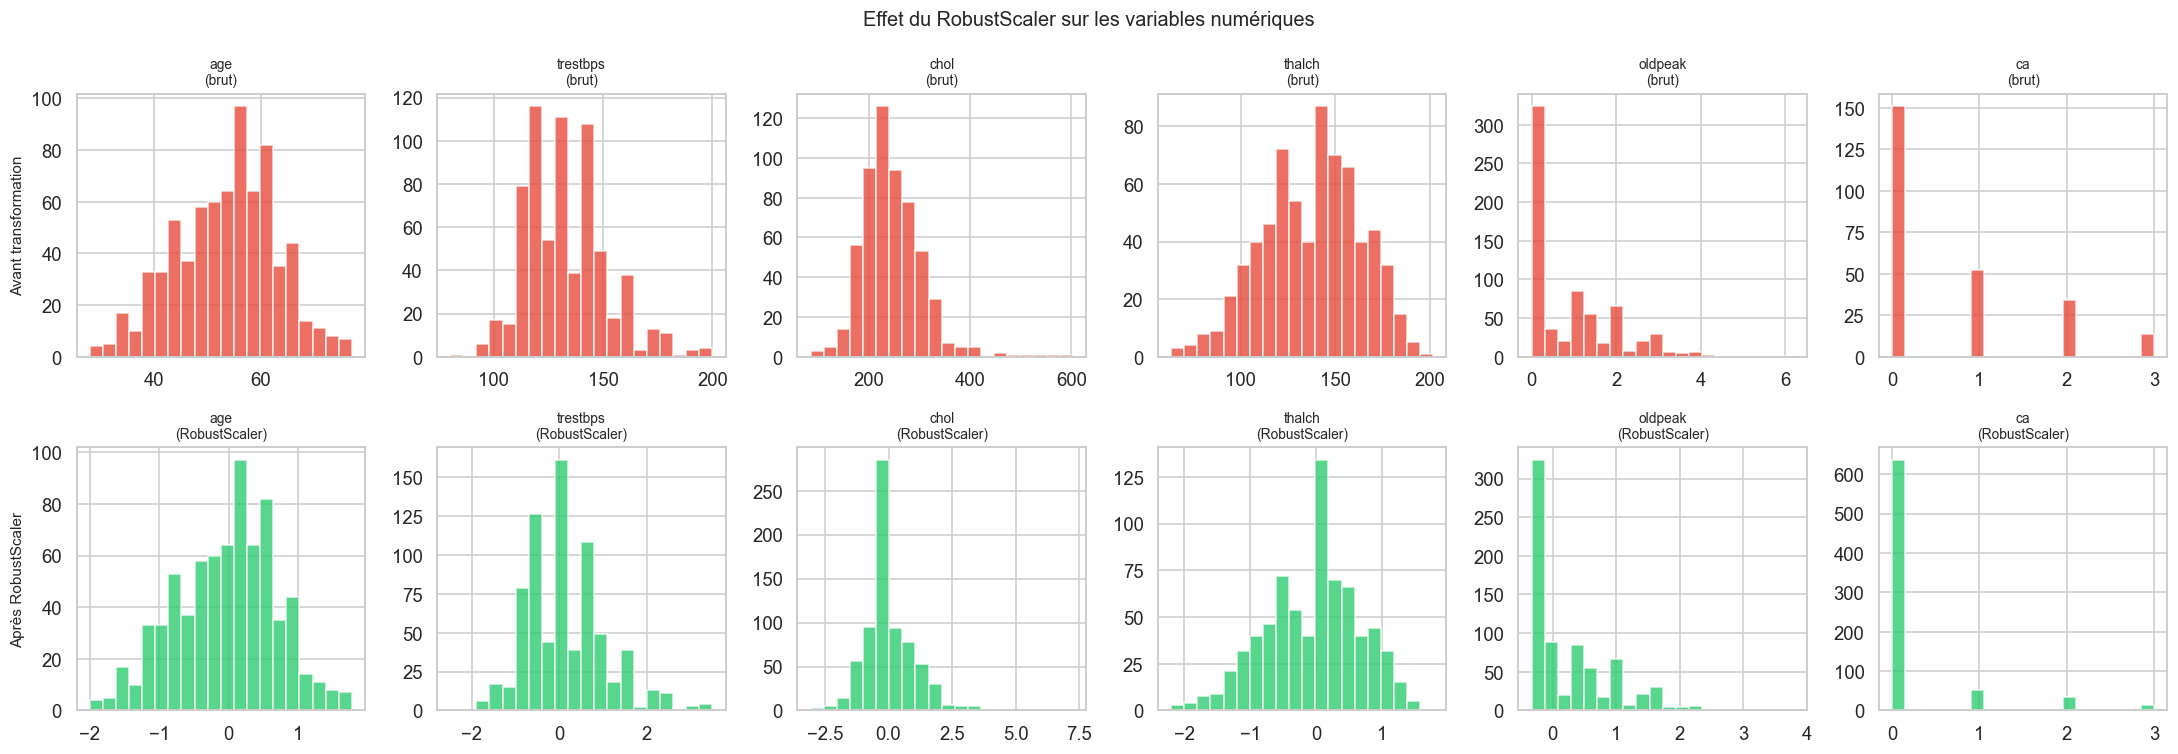

In [13]:
# Visualiser l'effet du RobustScaler
num_base = NUM_COLS[:6]  # les 6 numériques de base
num_idx  = [feature_names.index(c) for c in num_base]

fig, axes = plt.subplots(2, 6, figsize=(20, 7))
for i, (col, idx) in enumerate(zip(num_base, num_idx)):
    # Avant
    axes[0, i].hist(X_train[col].dropna(), bins=20, color='#e74c3c', edgecolor='white', alpha=0.8)
    axes[0, i].set_title(f'{col}\n(brut)', fontsize=9)
    # Après
    axes[1, i].hist(X_train_proc[:, idx], bins=20, color='#2ecc71', edgecolor='white', alpha=0.8)
    axes[1, i].set_title(f'{col}\n(RobustScaler)', fontsize=9)

axes[0, 0].set_ylabel('Avant transformation', fontsize=10)
axes[1, 0].set_ylabel('Après RobustScaler', fontsize=10)
plt.suptitle('Effet du RobustScaler sur les variables numériques', fontsize=13)
plt.tight_layout()
plt.savefig(FIGS_PATH / '10_robust_scaler_effect.png', dpi=150, bbox_inches='tight')
plt.show()

### 9 — SMOTE (équilibrage du train)

Distribution AVANT SMOTE :
  Classe 0 : 329 (44.7%)
  Classe 1 : 407 (55.3%)

Distribution APRÈS SMOTE :
  Classe 0 : 407 (50.0%)
  Classe 1 : 407 (50.0%)


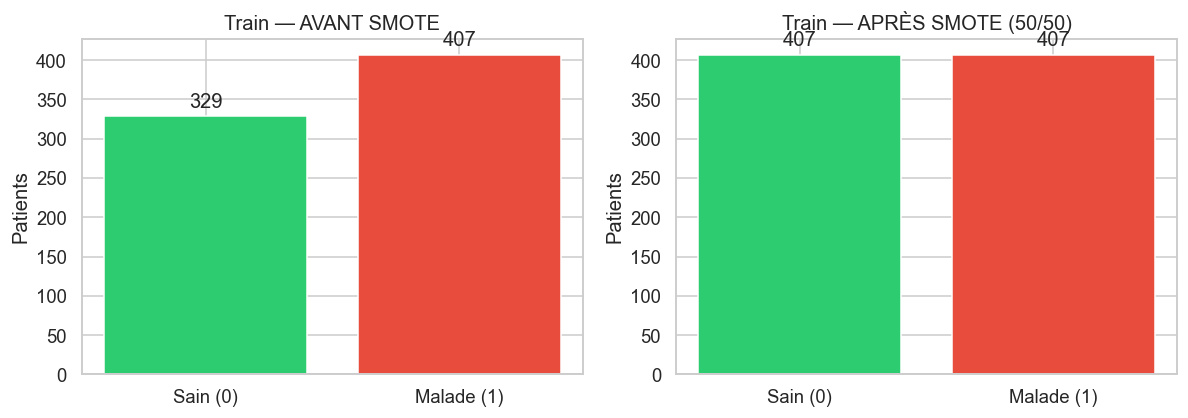


→ SMOTE génère des exemples synthétiques de la classe minoritaire
  par interpolation entre voisins proches dans l'espace des features
  IMPORTANT : appliqué sur le train seulement, pas sur le test ✓


In [14]:
from imblearn.over_sampling import SMOTE

print('Distribution AVANT SMOTE :')
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Classe {u} : {c} ({c/len(y_train):.1%})')

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_proc, y_train)

print('\nDistribution APRÈS SMOTE :')
unique, counts = np.unique(y_train_bal, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Classe {u} : {c} ({c/len(y_train_bal):.1%})')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
labels = ['Sain (0)', 'Malade (1)']
colors = ['#2ecc71', '#e74c3c']

u_before, c_before = np.unique(y_train, return_counts=True)
u_after,  c_after  = np.unique(y_train_bal, return_counts=True)

axes[0].bar(labels, c_before, color=colors, edgecolor='white')
axes[0].bar_label(axes[0].containers[0], padding=3)
axes[0].set_title('Train — AVANT SMOTE')
axes[0].set_ylabel('Patients')

axes[1].bar(labels, c_after, color=colors, edgecolor='white')
axes[1].bar_label(axes[1].containers[0], padding=3)
axes[1].set_title('Train — APRÈS SMOTE (50/50)')
axes[1].set_ylabel('Patients')

plt.tight_layout()
plt.savefig(FIGS_PATH / '11_smote_balance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n→ SMOTE génère des exemples synthétiques de la classe minoritaire')
print('  par interpolation entre voisins proches dans l\'espace des features')
print('  IMPORTANT : appliqué sur le train seulement, pas sur le test ✓')

### 10 — Vérification finale & sauvegarde

In [16]:
# Lancer le script complet pour sauvegarder les fichiers
import sys
sys.path.insert(0, '..')
from src.preprocess import main
main()


  PIPELINE DE PRÉTRAITEMENT — Heart Disease UCI

[load]  920 lignes × 16 colonnes
[clean] chol=0 → NaN : 172 valeurs
[clean] trestbps=0 → NaN : 1 valeur
[clean] oldpeak<0 → 0 : 12 valeurs
[target] Distribution : {0: np.int64(411), 1: np.int64(509)}
[feat]  Features ajoutées : ca_missing, thal_missing, chol_per_age, thalch_ratio

[split] Train=736  Test=184  (pos_rate train=0.553  test=0.554)

[preproc] X_train : (736, 26)  X_test : (184, 26)
[preproc] Features finales (26) : ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'chol_per_age', 'thalch_ratio', 'fbs', 'exang', 'ca_missing', 'thal_missing', 'sex', 'restecg', 'slope', 'cp_asymptomatic', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'thal_fixed defect', 'thal_normal', 'thal_reversable defect', 'dataset_Cleveland', 'dataset_Hungary', 'dataset_Switzerland', 'dataset_VA Long Beach']

[smote] Avant : {np.int64(0): np.int64(329), np.int64(1): np.int64(407)}
[smote] Après : {np.int64(0): np.int64(407), np.int64(1

In [17]:
# Vérification des fichiers sauvegardés
X_train_f = np.load(PROC_PATH / 'X_train.npy')
X_test_f  = np.load(PROC_PATH / 'X_test.npy')
y_train_f = np.load(PROC_PATH / 'y_train.npy')
y_test_f  = np.load(PROC_PATH / 'y_test.npy')
feat_names = np.load(PROC_PATH / 'feature_names.npy', allow_pickle=True)

print('=== VÉRIFICATION FINALE ===')
print(f'X_train : {X_train_f.shape}   y_train : {y_train_f.shape}')
print(f'X_test  : {X_test_f.shape}    y_test  : {y_test_f.shape}')
print(f'Features ({len(feat_names)}) : {list(feat_names)}')
print(f'Valeurs manquantes restantes : {np.isnan(X_train_f).sum()}')
print(f'Ratio malades (train) : {y_train_f.mean():.3f}')
print(f'Ratio malades (test)  : {y_test_f.mean():.3f}')

# DataFrame aperçu
pd.DataFrame(X_train_f, columns=feat_names).head(5)

=== VÉRIFICATION FINALE ===
X_train : (814, 26)   y_train : (814,)
X_test  : (184, 26)    y_test  : (184,)
Features (26) : [np.str_('age'), np.str_('trestbps'), np.str_('chol'), np.str_('thalch'), np.str_('oldpeak'), np.str_('ca'), np.str_('chol_per_age'), np.str_('thalch_ratio'), np.str_('fbs'), np.str_('exang'), np.str_('ca_missing'), np.str_('thal_missing'), np.str_('sex'), np.str_('restecg'), np.str_('slope'), np.str_('cp_asymptomatic'), np.str_('cp_atypical angina'), np.str_('cp_non-anginal'), np.str_('cp_typical angina'), np.str_('thal_fixed defect'), np.str_('thal_normal'), np.str_('thal_reversable defect'), np.str_('dataset_Cleveland'), np.str_('dataset_Hungary'), np.str_('dataset_Switzerland'), np.str_('dataset_VA Long Beach')]
Valeurs manquantes restantes : 0
Ratio malades (train) : 0.500
Ratio malades (test)  : 0.554


,age,trestbps,chol,thalch,oldpeak,ca,chol_per_age,thalch_ratio,fbs,exang,...,cp_atypical angina,cp_non-anginal,cp_typical angina,thal_fixed defect,thal_normal,thal_reversable defect,dataset_Cleveland,dataset_Hungary,dataset_Switzerland,dataset_VA Long Beach
0,-0.076923,1.50,0.000000,-0.514286,-0.333333,0.0,0.000000,-0.527809,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,1.538462,0.00,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,-0.076923,-0.30,0.079602,-0.514286,1.000000,0.0,-0.013247,-0.527809,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.538462,0.50,-0.636816,-0.057143,0.933333,1.0,-1.058867,0.147048,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
4,0.153846,1.25,0.000000,-1.171429,-0.333333,0.0,0.000000,-1.151063,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
